### Install library dependencies

In [ ]:
%pip install --upgrade pip
%pip install update pip
%pip install PyMuPDF==1.23.26
%pip install matplotlib==3.8.3
%pip install numpy==1.26.4
%pip install pandas==2.2.1
%pip install Requests==2.31.0 
%pip install sentence_transformers==2.5.1
%pip install spacy
%pip install tqdm==4.66.2 
%pip install transformers==4.38.2
%pip install accelerate
%pip install bitsandbytes
%pip install jupyter
%pip install wheel
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
%pip install pyarrow
%pip install fastparquet
%pip install datasets
%pip install rouge_score
%pip install bert-score
%pip install -q -U google-genai
%pip install seaborn

### Imports

In [27]:
import base64
import json
import logging
import numpy as np
import os
import pandas as pd
import random
import requests
import textwrap
import torch
from bert_score import score
from collections import defaultdict
from datasets import load_dataset
from google import genai
from google.genai import types
from keybert import KeyBERT
from rouge_score import rouge_scorer
from sentence_transformers import util, SentenceTransformer
from time import perf_counter as timer
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers.utils import is_flash_attn_2_available 

logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
model_id = "google/gemma-2b-it"
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)
if torch.cuda.is_available():
    embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", device="cuda")
    embedding_model.to("cuda")
else:
    embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", device="cpu")
    embedding_model.to("cpu")

### Helper functions

In [ ]:
def get_keywords(text, kw_model, range=(1, 4)):
    """
    Extract keywords from the given text using KeyBERT.
    """
    # kw_model = KeyBERT()
    try:
        keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=range)
    except Exception as e:
        print(f"Error extracting keywords: {e}")
        return []
    
    keywords_str = " ".join([keyword for keyword, score in keywords])

    word_scores = defaultdict(lambda: {'total_score': 0, 'count': 0})

    for phrase, score in keywords:
        words = phrase.split()
        for word in words:
            word_scores[word]['total_score'] += score
            word_scores[word]['count'] += 1

    # Calculate the average score for each word
    average_scores = {word: data['total_score'] / data['count'] for word, data in word_scores.items()}

    # Sort words by their average score in descending order
    sorted_words = sorted(average_scores.items(), key=lambda item: item[1], reverse=True)
    # print("Sorted Words:", sorted_words)   

    question = text.lower().replace("?", "").split()

    res = []
    for word in question:
        if word not in res: 
            if word in [word for word, _ in sorted_words] :
                res.append(word)

    words = " "
    words = words.join(res)

    return words

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=False):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query, 
                                   convert_to_tensor=True) 

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores, 
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict],
                                 n_resources_to_return: int=5,
                                 debug=False):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """
    
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)
    
    if(debug):
        print(f"Query: {query}\n")
        print("Results:")
    # Loop through zipped together scores and indicies
    chunks = []
    for score, index in zip(scores, indices):
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        chunks.append(pages_and_chunks[index])
        if(debug):
            print(f"Score: {score:.4f}")
            print_wrapped(pages_and_chunks[index]['text'])
        # Print the page number too so we can reference the textbook further and check the results
            print(f"id: {pages_and_chunks[index]['id']}\n")
    return chunks, indices

def make_chat_queries(sentence, input_sentence, context_items: list[dict], indices = []):
    kw_model = KeyBERT()
    keywords = get_keywords(sentence, kw_model)
    #context items contain a string of text with a system context, prompt and result
    #the system context should only appear once if it is shared across multiple items
    #the prompt and result should be unique to each item
    #count the number of unique system contexts in the context items
    system_contexts = set()
    for item in context_items:
        system_contexts.add(item['text'].split("\n")[0])
    #if there is only one system context, use it as the system context for the query
    if len(system_contexts) == 1:
        system_context = list(system_contexts)[0]
    else:
        system_context = " ".join([item['text'].split("\n")[0] for item in context_items])
    #if there are multiple system contexts, use the first one as the system context for the query
    example_shots = []
    example_shots_full = []
    for index, item in enumerate(context_items[1:]):
        #get the prompt and result from the item
        prompt = item['text'].split("\n")[1]
        result = item['text'].split("\n")[2]

        prompt_full = ds['train'][int(indices[index])]['question']
        #add the prompt and result to the example shots
        example_shots.append(f"{prompt}\n{result}")
        example_shots_full.append(f"prompt: {prompt_full}\n{result}")

    example_shots = "\n".join(example_shots)
    example_shots_full = "\n".join(example_shots_full)

    base_prompt = f"""Use the provided system context to generate an answer to the user's question
{system_context}

first, use the keywords to interpret the user's question
Analyse the following prompt-result pairs to understand the task better.
{example_shots}

Now interpret the keywords and answer with a single noun phrase
prompt: {keywords}"""
    messages = [
        {"role": "user", "content": base_prompt},
    ]

    # Combine the messages into a single prompt
    prompt = tokenizer.apply_chat_template(conversation=messages,
                                           tokenize=False,
                                           add_generation_prompt=True)

    full_prompt = f"""Use the provided system context to generate an answer to the user's question
{system_context}

first, interpret the user's question
Analyse the following prompt-result pairs to understand the task better.
{example_shots_full}

Now answer with a single noun phrase
prompt: {sentence}"""
    
    messages = [
        {"role": "user", "content": full_prompt},
    ]

    # Combine the messages into a single prompt
    prompt_control = tokenizer.apply_chat_template(conversation=messages,
                                           tokenize=False,
                                           add_generation_prompt=True)
    return prompt, prompt_control

def make_chat_query(sentence, input_sentence, context_items: list[dict], indices = []):
    system_contexts = set()
    for item in context_items:
        system_contexts.add(item['text'].split("\n")[0])

    if len(system_contexts) == 1:
        system_context = list(system_contexts)[0]
    else:
        system_context = " ".join([item['text'].split("\n")[0] for item in context_items])
    example_shots_full = []
    for index, item in enumerate(context_items[1:]):
        prompt = item['text'].split("\n")[1]
        result = item['text'].split("\n")[2]
        
        example_shots_full.append(f"{prompt}\n{result}")
    example_shots_full = "\n".join(example_shots_full)

    full_prompt = f"""Use the provided system context to generate an answer to the user's question
{system_context}

first, interpret the user's question
Analyse the following prompt-result pairs to understand the task better.
{example_shots_full}

Now answer with a single noun phrase
prompt: {sentence}"""
    return full_prompt

def gemma_format(input):
    messages = [
        {"role": "user", "content": input},
    ]

    prompt = tokenizer.apply_chat_template(conversation=messages,
                                           tokenize=False,
                                           add_generation_prompt=True)
    return prompt

def bert_score_compare(experiment_answer, control_answer, expected_answer, debug=False):

    candidates = [experiment_answer, control_answer]
    references = [expected_answer, expected_answer]

    P, R, F1 = score(candidates, references, lang="en", verbose=False)

    if debug:
        print(f"Experiment Precision: {P[0].item():.6f}")
        print(f"Experiment Recall: {R[0].item():.6f}")
        print(f"Experiment F1: {F1[0].item():.6f}")

        print(f"Control Precision: {P[1].item():.6f}")
        print(f"Control Recall: {R[1].item():.6f}")
        print(f"Control F1: {F1[1].item():.6f}")
    return P, R, F1

def bert_score(answer, truth, debug=False):

    candidates = [answer]
    references = [truth]

    P, R, F1 = score(candidates, references, lang="en", verbose=False)

    if debug:
        print(f"Experiment Precision: {P[0].item():.6f}")
        print(f"Experiment Recall: {R[0].item():.6f}")
        print(f"Experiment F1: {F1[0].item():.6f}")
    return P, R, F1


def get_answer_from_huggingface_api(prompt: str, key: str, model: str = "deepseek/deepseek-v3-0324"):
    """
    Get answer from Hugging Face API using the provided prompt and model.
    """
    API_URL = "https://router.huggingface.co/novita/v3/openai/chat/completions"
    headers = {"Authorization": "Bearer "+ key }
    payload = {
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "model": model,
    }

    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()["choices"][0]["message"]['content']

def retrieve_and_compare(experiment, control, debug=False):
    start_time = timer()
    experiment_answer = remote_infer(experiment)
    end_time = timer()
    if debug:
        print(f"[INFO] Time taken for cut: {end_time-start_time:.5f} seconds.")

    start_time = timer()
    control_answer = remote_infer(control)
    end_time = timer()
    if debug:
        print(f"[INFO] Time taken for full: {end_time-start_time:.5f} seconds.")

    return experiment_answer, control_answer

def remote_infer(input, api_key):
    client = genai.Client(api_key)

    response = client.models.generate_content(
        model="gemini-2.0-flash"
        , contents=input
    )
    return(response.text)

def demo_index(index, kw_model = KeyBERT(), debug=False):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

    query_system = ds['train'][index]['context'].lower()
    query_prompt = ds['train'][index]['question'].lower()

    query = f'''system: {query_system}
    prompt: {query_prompt}
    result: '''

    chunks, indices = print_top_results_and_scores(query=query, embeddings=embeddings_full, debug=False, pages_and_chunks=pages_and_chunks_full)
    control = make_chat_query(query_prompt, query_system, chunks, indices)
    # print(control)

    keywords = get_keywords(query_prompt, kw_model)
    
    query = f'''system: {query_system}
    prompt: {keywords}
    result: '''

    chunks, indices = print_top_results_and_scores(query=query, embeddings=embeddings, debug=False, pages_and_chunks=pages_and_chunks)
    experiment = make_chat_query(keywords, query_system, chunks, indices)
    # print(experiment)

    experiment_answer, control_answer = retrieve_and_compare(experiment, control, debug=True)
    expected_answer = ds['train'][index]['answers']['text'][0]

    cut_len = len(keywords)
    full_len = len(query_prompt)

    experiment_scores = scorer.score(experiment_answer,
                        expected_answer)

    control_scores = scorer.score(control_answer,
                        expected_answer)
    if debug:
        print(f"Length of cut question:  {cut_len}")
        print(f"Length of full question: {full_len}")
        print(f"Time saving of {round((full_len-cut_len)/3, 2)} seconds")

        print(f"question asked: {query_prompt}")
        print(f"Expected answer: {expected_answer}")

        print(f"Experiment answer: {experiment_answer}")
        print(f"Control answer: {control_answer}")
        print(experiment_scores['rouge1'])
        print(control_scores['rouge1'])

    P, R, F1 = bert_score_compare(experiment_answer, control_answer, expected_answer)
    return {
        "index": index,
        "id": ds['train'][index]['id'],
        "experiment_answer": experiment_answer,
        "control_answer": control_answer,
        "expected_answer": expected_answer,
        "cut_len": cut_len,
        "full_len": full_len,
        "experiment_score": experiment_scores['rouge1'],
        "control_score": control_scores['rouge1'],
        "BERT_P": P[0].item(),
        "BERT_R": R[0].item(),
        "BERT_F1": F1[0].item(),
        "BERT_P_control": P[1].item(),
        "BERT_R_control": R[1].item(),
        "BERT_F1_control": F1[1].item(),
    }

### Download dataset

Stanford Question Answering Dataset (SQuAD) is a reading comprehension dataset, consisting of questions posed by crowdworkers on a set of Wikipedia articles, where the answer to every question is a segment of text, or span, from the corresponding reading passage, or the question might be unanswerable.

more details at:
https://huggingface.co/datasets/rajpurkar/squad

In [5]:
ds = load_dataset("rajpurkar/squad")
ds['train'][0]

{'id': '5733be284776f41900661182',
 'title': 'University_of_Notre_Dame',
 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.',
 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?',
 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}

We can see the properties of each data set.
One thing to note that the train and validation splits are not randomly split per data point, but instead by the subject of the question (the "title" property). The above example is about the University of Notre Dame, and this means that the validation split will not have any questions based on this subject.

In [ ]:
unique_titles_train = set()
for item in ds['train']:
    unique_titles_train.add(item['title'])

unique_titles_validation = set()
for item in ds['validation']:
    unique_titles_validation.add(item['title'])

# find titles that are in both train and validation sets
common_titles = unique_titles_train.intersection(unique_titles_validation)
print(f"Number of common titles: {len(common_titles)}")

Be aware, this dataset has an outlier, one of the input questions is surrounded by thousands of whitespace characters! deal with this how you like

In [ ]:
len(ds['train'][75237]['question']) - len(ds['train'][75237]['question'].strip())

### Extract keywords from context and question

We're going to use some of the previously defined functions to create 'distilled' versions of the data. This code will extract the keywords, and at the same time, restructure our dataset to remove unused properties.

In [ ]:
%%time

llama2_dataset = []

kw_model = KeyBERT()

# for i in range(10):
for i in range(len(ds['train'])):
  if(i % 10000 == 0):
    print(i)

  context_words = get_keywords(ds['train'][i]['context'], kw_model)
  question_words = get_keywords(ds['train'][i]['question'], kw_model)

  data_point = {
    "id": ds['train'][i]['id'],
    "context_full": ds['train'][i]['context'],
    "context_cut": context_words,
    "question_full": ds['train'][i]['question'],
    "question_cut": question_words,
    "result_text": ds['train'][i]['answers']['text'][0]
  }
  llama2_dataset.append(data_point)

print(f"Dataset created with {len(llama2_dataset)} entries.")

### Save to disk

In [ ]:
with open('SQuAD_llama2_dataset.json', 'w') as f:
    json.dump(llama2_dataset, f, indent=4)

### Load from disk

In [23]:
llama2_dataset = []

with open('SQuAD_llama2_dataset.json', 'r') as f:
    llama2_dataset = json.load(f)

### Create embeddings

Embeddings are numerical representations of text data that capture the semantic meaning of words, phrases, or sentences in a continuous vector space. They are used to transform textual data into a format that machine learning models can process effectively.
These embeddings will be used to efficiently facilitate retrieval-augmented generation

#### For the control

In [ ]:
%%time

llama2_dataset_concat = []
for l2_d in llama2_dataset:
    llama2_dataset_concat.append({"id": l2_d['id'],
                                  "text": "system: " + l2_d['context_full'] + "\nprompt: " + l2_d['question_full'] + "\nresult: " + l2_d['result_text']})

llama2_dataset_concat[0]

import json

with open('SQuAD_llama2_dataset_concat_full.json', 'w') as f:
    json.dump(llama2_dataset_concat, f, indent=4)

# # Embed each chunk one by one
for item in tqdm(llama2_dataset_concat):
    item["embedding"] = embedding_model.encode(item["text"])
    
text_chunks_and_embeddings_df = pd.DataFrame(llama2_dataset_concat)
embeddings_df_save_path = "SQuAD_embeddings_full.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

#### For the reduced question

In [ ]:
%%time

llama2_dataset_concat = []
for l2_d in llama2_dataset:
    llama2_dataset_concat.append({"id": l2_d['id'],
                                  "text": "system: " + l2_d['context_full'] + "\nprompt: " + l2_d['question_cut'] + "\nresult: " + l2_d['result_text']})

llama2_dataset_concat[0]

import json

with open('SQuAD_llama2_dataset_concat_cutquestion.json', 'w') as f:
    json.dump(llama2_dataset_concat, f, indent=4)

# # Embed each chunk one by one
for item in tqdm(llama2_dataset_concat):
    item["embedding"] = embedding_model.encode(item["text"])

text_chunks_and_embeddings_df = pd.DataFrame(llama2_dataset_concat)
embeddings_df_save_path = "SQuAD_embeddings_cutquestion.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

#### For the reduced context

In [ ]:
%%time
llama2_dataset_concat = []
for l2_d in llama2_dataset:
    llama2_dataset_concat.append({"id": l2_d['id'],
                                  "text": "system: " + l2_d['context_cut'] + "\nprompt: " + l2_d['question_full'] + "\nresult: " + l2_d['result_text']})

llama2_dataset_concat[0]

import json

with open('SQuAD_llama2_dataset_concat_cutcontext.json', 'w') as f:
    json.dump(llama2_dataset_concat, f, indent=4)
# # Embed each chunk one by one
for item in tqdm(llama2_dataset_concat):
    item["embedding"] = embedding_model.encode(item["text"])
    
text_chunks_and_embeddings_df = pd.DataFrame(llama2_dataset_concat)
embeddings_df_save_path = "SQuAD_embeddings_cutcontext.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

### Load and convert RAG Embeddings

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
SQuAD_embeddings_cutquestion = pd.read_csv("SQuAD_embeddings_cutquestion.csv")

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
SQuAD_embeddings_cutquestion["embedding"] = SQuAD_embeddings_cutquestion["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
pages_and_chunks = SQuAD_embeddings_cutquestion.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(SQuAD_embeddings_cutquestion["embedding"].tolist()), dtype=torch.float32).to(device)
# embeddings.shape

SQuAD_embeddings_full = pd.read_csv("SQuAD_embeddings_full.csv")
SQuAD_embeddings_full["embedding"] = SQuAD_embeddings_full["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
pages_and_chunks_full = SQuAD_embeddings_full.to_dict(orient="records")
embeddings_full = torch.tensor(np.array(SQuAD_embeddings_full["embedding"].tolist()), dtype=torch.float32).to(device)

torch.Size([87599, 768])

### Make all prompts

A prompt is the input or instruction provided to a language model to guide its response. It can include a question, a statement, or a specific task description. The quality and structure of the prompt significantly influence the model's output, making it a critical component in interacting with AI systems.

Now we're going to run RAG on every data point and generate a prompt as output. This is not running the prompt yet, simply preparing it for a batch job later on in the notebook.

Context items will be fetched from our RAG database. As the dataset did not have a properly partitioned train and validation splits, our RAG database is using the same dataset as the data we are using to perform the similarity match. This means that the RAG system is capable of retrieving the exact same context-question data point that it was asked to match - very effective!

Unfortunately this also includes the verbatim answer to the question, and the system stops working as hypothesized. To circumvent this, it is assumed that each retrieval instance contains 'itself' as the top result, and is automatically discarded.

In [24]:
def get_queries_from_index(index, kw_model = KeyBERT(), debug=False):
    query_system = ds['train'][index]['context'].lower()
    query_prompt = ds['train'][index]['question'].lower()
    keywords = get_keywords(query_prompt, kw_model)

    query_control = f'''system: {query_system}
prompt: {query_prompt}
result: '''

    query_experiment = f'''system: {query_system}
prompt: {keywords}
result: '''

    chunks, indices = print_top_results_and_scores(query=query_control, embeddings=embeddings_full, debug=False, pages_and_chunks=pages_and_chunks_full)
    control = make_chat_query(query_prompt, query_system, chunks, indices)
    
    chunks, indices = print_top_results_and_scores(query=query_experiment, embeddings=embeddings, debug=False, pages_and_chunks=pages_and_chunks)
    experiment = make_chat_query(keywords, query_system, chunks, indices)

    return experiment, control

In [ ]:
e, _ = get_queries_from_index(0)

print(e)

Use the provided system context to generate an answer to the user's question
system: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.

first, interpret the user's question
Analyse the following prompt-result pairs to understand the task better.
prompt: grotto notre dame
result: a Marian place of prayer and reflection
prompt: sits main building notre d

In [ ]:
_, c = get_queries_from_index(0)

print(c)

Use the provided system context to generate an answer to the user's question
system: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.

first, interpret the user's question
Analyse the following prompt-result pairs to understand the task better.
prompt: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
result: the Main Buildi

In [ ]:
kw_model = KeyBERT()

exp_queries = 'queries_cut.jsonl'
con_queries = 'queries_full.jsonl'
# delete both files if they exist
if os.path.exists(exp_queries):
    os.remove(exp_queries)
if os.path.exists(con_queries):
    os.remove(con_queries)

ds = load_dataset("rajpurkar/squad")

for i in range(len(ds['train'])):
    if(i % 10000 == 0):
        print(i)
    e, c = get_queries_from_index(i, kw_model)

    e_obj = {
        'id': ds['train'][i]['id'],
        'request':{
            'contents': [{
                'role': 'user',
                'parts': [{
                    'text': e
                }]
            }]
        }
    }

    c_obj = {
        'id': ds['train'][i]['id'],
        'request':{
            'contents': [{
                'role': 'user',
                'parts': [{
                    'text': c
                }]
            }]
        }
    }

    with open(exp_queries, 'w') as fe:
        json.dump(e_obj, fe)
        fe.write('\n')
    
    with open(con_queries, 'w') as fc:
        json.dump(c_obj, fc)
        fc.write('\n')

### Batch run

Large Language Model inferrence takes a lot of processing power and time, and we have ~88000 data points. to speed this along, we are going to offload this processing to Google. You should have the queries prepared from the above section, but check that they match the below format.

In [ ]:
#required format for gemini
#one prompt object per line, with unique id for each
{"id": "prompt_001", "request": {"contents": [{"role": "user", "parts": [{"text": "What is the capital of France?"}]}]}}

We can then use the below notebook to run the batch predictions job. It's much easier to use their notebook than to include the code here.
https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/batch-prediction/intro_batch_prediction.ipynb

### Import predictions and calculate scores

In [34]:
experiment_file = "prediction-model-2025-05-06T10_04_33.625198Z_predictions.jsonl"
control_file = "prediction-model-2025-05-06T10_16_28.698278Z_predictions.jsonl"

In [35]:
# load up SQuAD_llama2_dataset.json
with open('SQuAD_llama2_dataset.json', 'r') as f:
    llama2_dataset = json.load(f)

experiment_predictions = []
with open(experiment_file, 'r', encoding='utf-8') as f:
    for line in f:
        experiment_predictions.append(json.loads(line))

control_predictions = []
with open(control_file, 'r', encoding='utf-8') as f:
    for line in f:
        control_predictions.append(json.loads(line))

# make predictions indexable by id
experiment_predictions_df = pd.DataFrame(experiment_predictions)
experiment_predictions_df.set_index('id', inplace=True)
control_predictions_df = pd.DataFrame(control_predictions)
control_predictions_df.set_index('id', inplace=True)

In [ ]:
%%time
import os
from datetime import datetime

results = []
outfile = 'results_'+datetime.now().strftime("%d_%m")+'.json'
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
#read the number of lines in the file
num_lines = 0
if os.path.exists(outfile):
    with open(outfile, 'r', encoding='utf-8') as f:
        num_lines = sum(1 for line in f)
print(f"Number of lines in {outfile}: {num_lines}")

# start the loop from the number of lines in the file
for i in range(num_lines, len(llama2_dataset)):
    if (i % 1000==0):
        print(i)
    ld = llama2_dataset[i]
    actual_answer = ld['result_text']
    experiment_object = experiment_predictions_df.loc[ld['id']]
    experiment_answer = experiment_object['response']['candidates'][0]['content']['parts'][0]['text']
    experiment_answer = experiment_answer.strip()
    control_object = control_predictions_df.loc[ld['id']]
    control_answer = control_object['response']['candidates'][0]['content']['parts'][0]['text']
    control_answer = control_answer.strip()
    experiment_score = scorer.score(actual_answer, experiment_answer)
    control_score = scorer.score(actual_answer, control_answer)

    # compute the BERT score for the experiment and control answers
    P, R, F1 = bert_score_compare(experiment_answer, control_answer, actual_answer)
    # compute the time saving
    cut_len = len(ld['question_cut'])
    full_len = len(ld['question_full'].strip())
    time_saving = (full_len-cut_len)*3/13

    result_object = {
        'id': ld['id'],
        'context_full': ld['context_full'],
        'question_full': ld['question_full'],
        'question_cut': ld['question_cut'],
        'len_question_full': full_len,
        'len_question_cut': cut_len,
        'time_saving': time_saving,
        'actual_answer': actual_answer,
        'experiment_answer': experiment_answer,
        'control_answer': control_answer,
        'rouge1_experiment_precision': experiment_score['rouge1'].precision,
        'rouge1_experiment_recall': experiment_score['rouge1'].recall,
        'rouge1_experiment_fmeasure': experiment_score['rouge1'].fmeasure,
        'rougeL_experiment_precision': experiment_score['rougeL'].precision,
        'rougeL_experiment_recall': experiment_score['rougeL'].recall,
        'rougeL_experiment_fmeasure': experiment_score['rougeL'].fmeasure,
        'rouge1_control_precision': control_score['rouge1'].precision,
        'rouge1_control_recall': control_score['rouge1'].recall,
        'rouge1_control_fmeasure': control_score['rouge1'].fmeasure,
        'rougeL_control_precision': control_score['rougeL'].precision,
        'rougeL_control_recall': control_score['rougeL'].recall,
        'rougeL_control_fmeasure': control_score['rougeL'].fmeasure,
        'BERT_P': P[0].item(),
        'BERT_R': R[0].item(),
        'BERT_F1': F1[0].item(),
        'BERT_P_control': P[1].item(),
        'BERT_R_control': R[1].item(),
        'BERT_F1_control': F1[1].item(),
    }
    results.append(result_object)

    with open(outfile, 'a', encoding='utf-8') as f:
        json.dump(result_object, f, ensure_ascii=False)
        f.write('\n')

### Load results file

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

infile = 'results_21_05.json'
results_df = pd.read_json(infile, lines=True)

# Set the style of seaborn
sns.set(style="whitegrid")

#### Overall Accuracy

RougeL Fmeasure is a measure of the overlap between the generated answer and the expected answer. It is based on the longest common subsequence (LCS) between the two texts, which captures the order of words. RougeL is particularly useful for evaluating text summarization tasks.

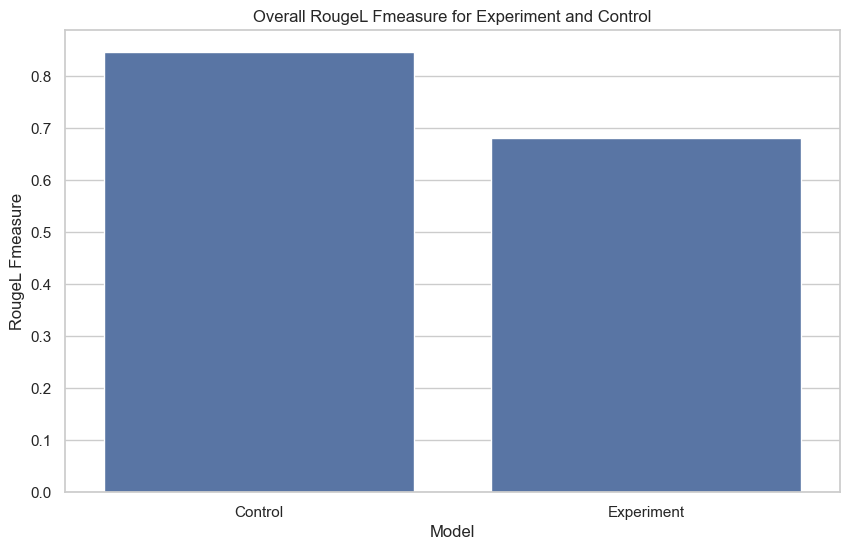

Control mean: 84.57%
Experiment mean: 68.05%
Percentage difference in means: 80.46%


In [ ]:
# Create a new figure
plt.figure(figsize=(10, 6))

# Create a bar plot for the overall rougeL fmeasure for experiment and control
sns.barplot(x=['Control', 'Experiment'], y=[results_df['rougeL_control_fmeasure'].mean(), results_df['rougeL_experiment_fmeasure'].mean()])

# Set the title and labels
plt.title('Overall RougeL Fmeasure for Experiment and Control')
plt.xlabel('Model')
plt.ylabel('RougeL Fmeasure')

# Show the plot
plt.show()

# print the mean for control and experiment as percentages
print(f"Control mean: {results_df['rougeL_control_fmeasure'].mean():.2%}")
print(f"Experiment mean: {results_df['rougeL_experiment_fmeasure'].mean():.2%}")

# print the difference in means as a percentage
percentage = results_df['rougeL_experiment_fmeasure'].mean()/results_df['rougeL_control_fmeasure'].mean()
print(f"Percentage difference in means: {percentage:.2%}")

BERT F1 score is a measure of the similarity between the generated answer and the expected answer. It is based on the BERT model, which captures semantic meaning and context better than traditional n-gram based metrics like ROUGE.

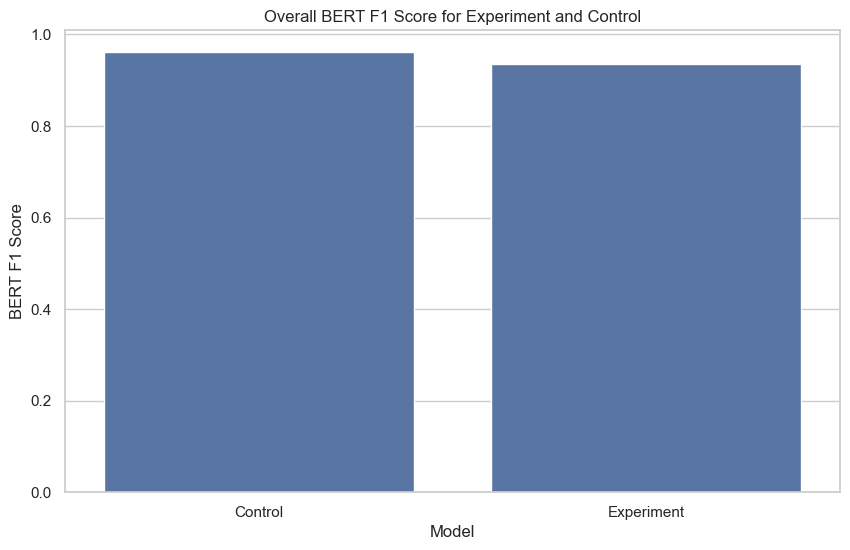

Control mean: 96.11%
Experiment mean: 93.61%
Percentage difference in means: 97.40%


In [ ]:
# Create a new figure
plt.figure(figsize=(10, 6))

# Create a bar plot for the overall BERT F1 score for experiment and control
sns.barplot(x=['Control', 'Experiment'], y=[results_df['BERT_F1_control'].mean(), results_df['BERT_F1'].mean()])

# Set the title and labels
plt.title('Overall BERT F1 Score for Experiment and Control')
plt.xlabel('Model')
plt.ylabel('BERT F1 Score')

# Show the plot
plt.show()

# print the mean for control and experiment as percentages
print(f"Control mean: {results_df['BERT_F1_control'].mean():.2%}")
print(f"Experiment mean: {results_df['BERT_F1'].mean():.2%}")

# print the difference in means as a percentage
percentage = results_df['BERT_F1'].mean()/results_df['BERT_F1_control'].mean()
print(f"Percentage difference in means: {percentage:.2%}")

#### Time savings

This is a calculation of how many seconds are saved by submitting a reduced-length and reduced-content prompt, when assuming that a person is typing at a standard rate of 3 characters per second.

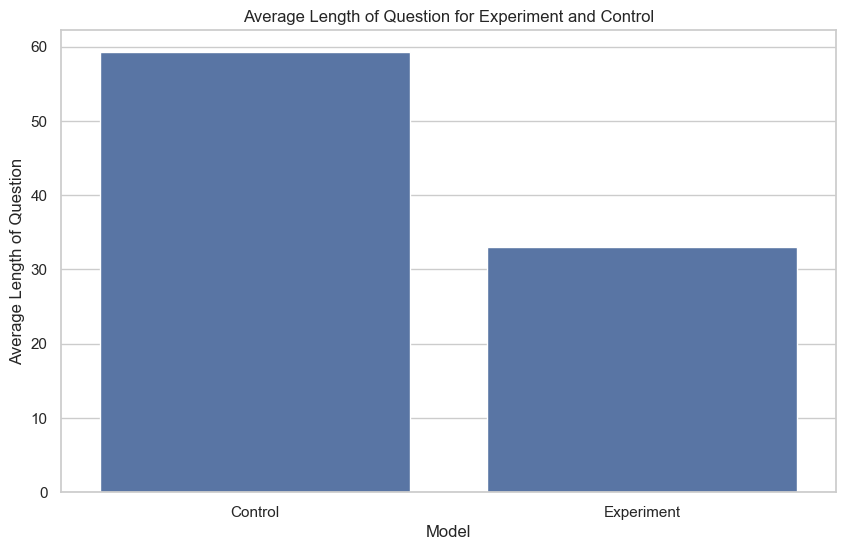

Control mean: 59.24
Experiment mean: 33.01
Percentage difference in means: 55.72%


In [4]:
#graph the average length of the question for control and experiment
plt.figure(figsize=(10, 6))

# Create a bar plot for the average length of the question for experiment and control
sns.barplot(x=['Control', 'Experiment'], y=[results_df['len_question_full'].mean(), results_df['len_question_cut'].mean()])

# Set the title and labels
plt.title('Average Length of Question for Experiment and Control')
plt.xlabel('Model')
plt.ylabel('Average Length of Question')

# Show the plot
plt.show()

# print the mean for control and experiment
print(f"Control mean: {results_df['len_question_full'].mean():.2f}")
print(f"Experiment mean: {results_df['len_question_cut'].mean():.2f}")

# print the difference in means as a percentage
percentage = results_df['len_question_cut'].mean()/results_df['len_question_full'].mean()
print(f"Percentage difference in means: {percentage:.2%}")

### Time Savings Distribution

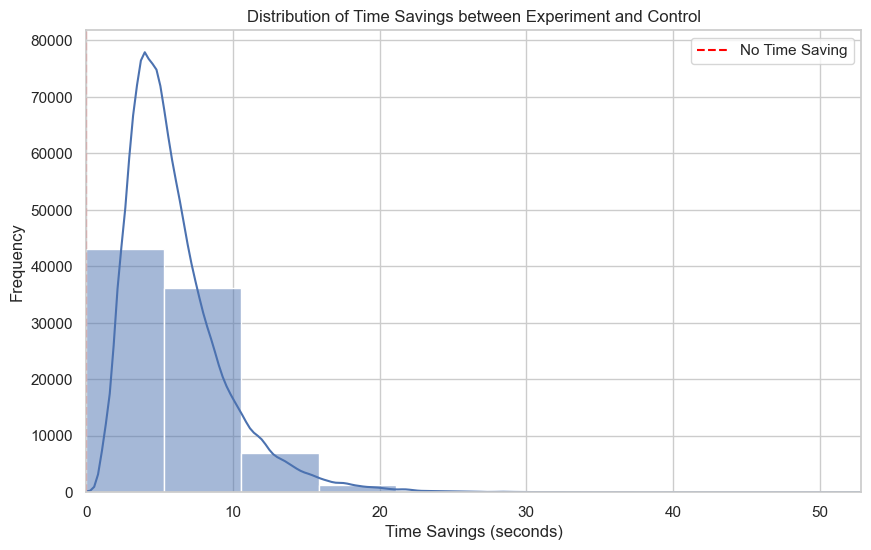

Min time saving: 0.00
Max time saving: 52.85


In [ ]:
min_time = results_df['time_saving'].min()
max_time = results_df['time_saving'].max()

plt.figure(figsize=(10, 6))

# Create a bar plot for the time savings for experiment and control
sns.histplot(data=results_df, x='time_saving', bins=10, kde=True)
plt.xlim(min_time, max_time)
plt.axvline(x=0, color='red', linestyle='--', label='No Time Saving')
plt.title('Distribution of Time Savings between Experiment and Control')
plt.xlabel('Time Savings (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Min time saving: {min_time:.2f}")
print(f"Max time saving: {max_time:.2f}")

### Time Savings Distribution - above mean

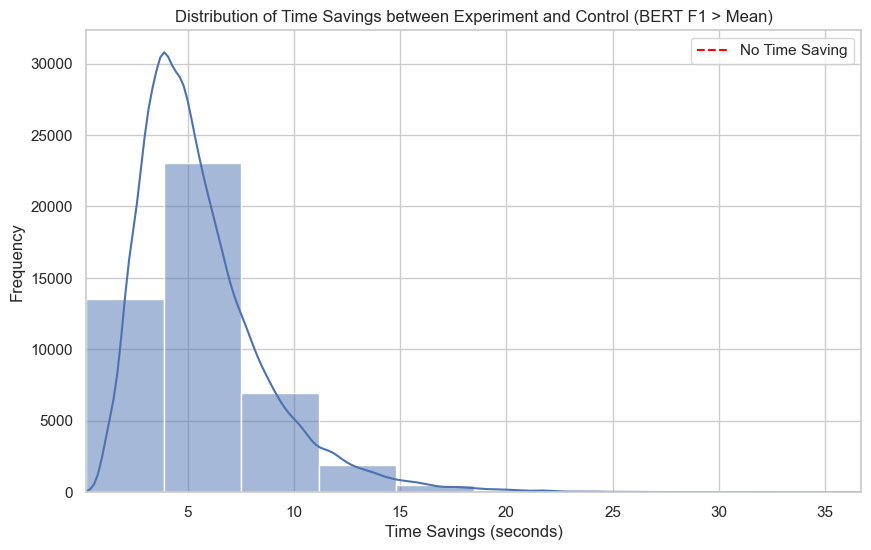

Mean BERT F1 score: 96.11%
Number of rows in filtered results_df: 46153
Min time saving: 0.23
Max time saving: 36.69


In [ ]:
mean_bert_f1 = results_df['BERT_F1_control'].mean()
# filter the results_df to only include the rows where the BERT F1 score is greater than the median BERT F1 score for the control
results_df_filtered = results_df[results_df['BERT_F1'] > mean_bert_f1]
min_time = results_df_filtered['time_saving'].min()
max_time = results_df_filtered['time_saving'].max()
plt.figure(figsize=(10, 6))
# Create a bar plot for the time savings for experiment and control
sns.histplot(data=results_df_filtered, x='time_saving', bins=10, kde=True)
plt.xlim(min_time, max_time)
plt.axvline(x=0, color='red', linestyle='--', label='No Time Saving')
plt.title('Distribution of Time Savings between Experiment and Control (BERT F1 > Mean)')
plt.xlabel('Time Savings (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.show()
print(f"Mean BERT F1 score: {mean_bert_f1:.2%}")
#print the number of rows in the filtered results_df
print(f"Number of rows in filtered results_df: {len(results_df_filtered)}")
print(f"Min time saving: {min_time:.2f}")
print(f"Max time saving: {max_time:.2f}")



### Time Savings Distribution - above median

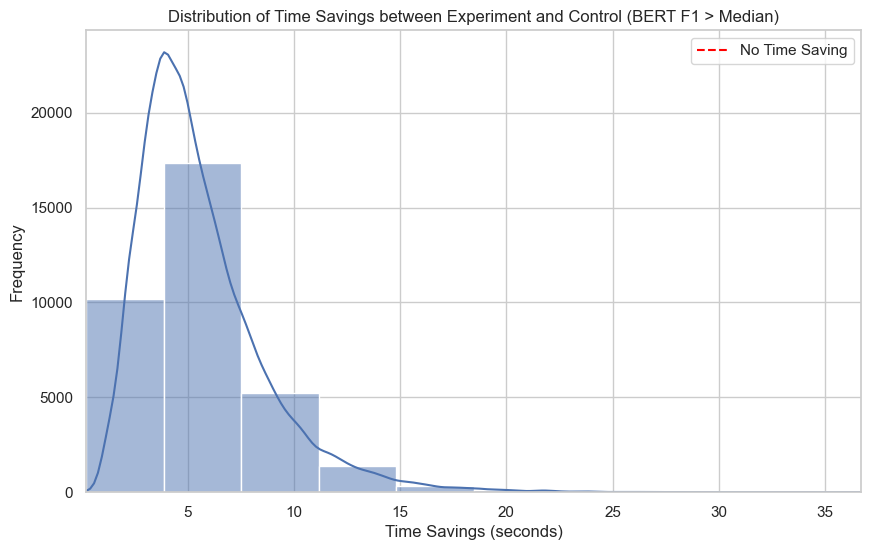

Median BERT F1 score: 100.00%
Number of rows in filtered results_df: 34628
Min time saving: 0.23
Max time saving: 36.69


In [ ]:
median_bert_f1 = results_df['BERT_F1_control'].median()
# filter the results_df to only include the rows where the BERT F1 score is greater than the median BERT F1 score for the control
results_df_filtered = results_df[results_df['BERT_F1'] > median_bert_f1]
min_time = results_df_filtered['time_saving'].min()
max_time = results_df_filtered['time_saving'].max()
plt.figure(figsize=(10, 6))
# Create a bar plot for the time savings for experiment and control
sns.histplot(data=results_df_filtered, x='time_saving', bins=10, kde=True)
plt.xlim(min_time, max_time)
plt.axvline(x=0, color='red', linestyle='--', label='No Time Saving')
plt.title('Distribution of Time Savings between Experiment and Control (BERT F1 > Median)')
plt.xlabel('Time Savings (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.show()
print(f"Median BERT F1 score: {median_bert_f1:.2%}")
#print the number of rows in the filtered results_df
print(f"Number of rows in filtered results_df: {len(results_df_filtered)}")
print(f"Min time saving: {min_time:.2f}")
print(f"Max time saving: {max_time:.2f}")



### ROUGE score Distribution

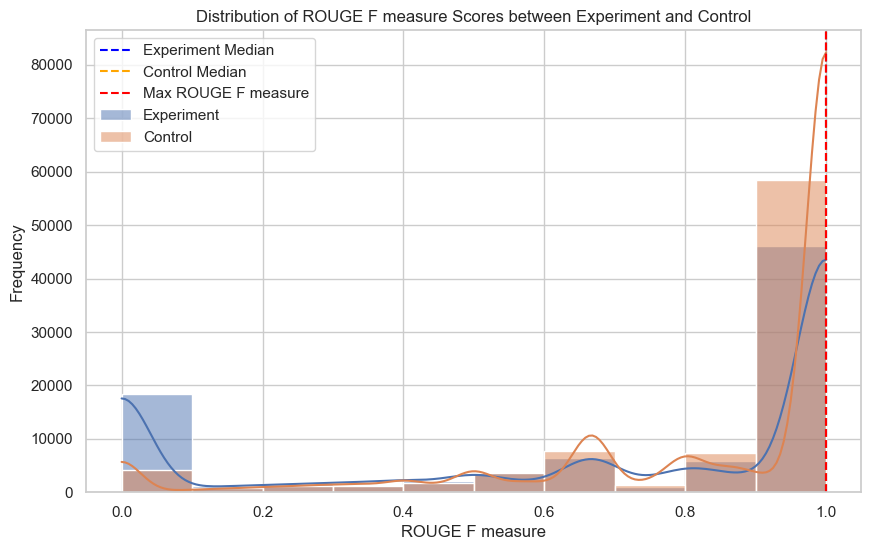

Median ROUGE F measure for experiment: 100.00%
Min ROUGE F measure for experiment: 0.00%
Max ROUGE F measure for experiment: 100.00%
Median ROUGE F measure for control: 100.00%
Min ROUGE F measure for control: 0.00%
Max ROUGE F measure for control: 100.00%


In [ ]:
median_bert_f1 = results_df['rougeL_experiment_fmeasure'].median()
median_bert_f1_control = results_df['rougeL_control_fmeasure'].median()
results_df_filtered = results_df

#make sure the bins are the same for both histograms
bins = np.linspace(0, 1, 11)
# Create a new figure
plt.figure(figsize=(10, 6))
# plt.xlim(0.5, 1.1)

sns.histplot(data=results_df_filtered, x='rougeL_experiment_fmeasure', bins=bins, kde=True, label='Experiment')
sns.histplot(data=results_df_filtered, x='rougeL_control_fmeasure', bins=bins, kde=True, label='Control')
plt.axvline(x=median_bert_f1, color='blue', linestyle='--', label='Experiment Median')
plt.axvline(x=median_bert_f1_control, color='orange', linestyle='--', label='Control Median')
plt.title('Distribution of ROUGE F measure Scores between Experiment and Control')
plt.xlabel('ROUGE F measure')
plt.ylabel('Frequency')
# put a marker at 1.0 to show the maximum limit of BERT F1 score
plt.axvline(x=1.0, color='red', linestyle='--', label='Max ROUGE F measure')
plt.legend()
plt.show()

print(f"Median ROUGE F measure for experiment: {median_bert_f1:.2%}")
print(f"Min ROUGE F measure for experiment: {results_df_filtered['rougeL_experiment_fmeasure'].min():.2%}")
print(f"Max ROUGE F measure for experiment: {results_df_filtered['rougeL_experiment_fmeasure'].max():.2%}")
print(f"Median ROUGE F measure for control: {median_bert_f1_control:.2%}")
print(f"Min ROUGE F measure for control: {results_df_filtered['rougeL_control_fmeasure'].min():.2%}")
print(f"Max ROUGE F measure for control: {results_df_filtered['rougeL_control_fmeasure'].max():.2%}")


### BERTScore Distribution

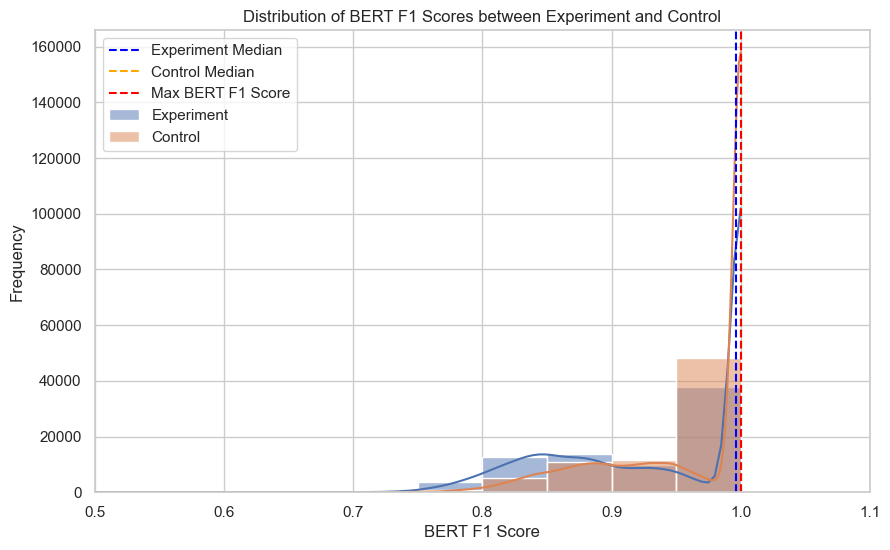

Median BERT F1 score for experiment: 99.67%
Min BERT F1 score for experiment: 0.00%
Max BERT F1 score for experiment: 100.00%
Median BERT F1 score for control: 100.00%
Min BERT F1 score for control: 70.18%
Max BERT F1 score for control: 100.00%


In [ ]:
median_bert_f1 = results_df['BERT_F1'].median()
median_bert_f1_control = results_df['BERT_F1_control'].median()
results_df_filtered = results_df

#make sure the bins are the same for both histograms
bins = np.linspace(0.5, 1, 11)
# Create a new figure
plt.figure(figsize=(10, 6))
plt.xlim(0.5, 1.1)

sns.histplot(data=results_df_filtered, x='BERT_F1', bins=bins, kde=True, label='Experiment')
sns.histplot(data=results_df_filtered, x='BERT_F1_control', bins=bins, kde=True, label='Control')
plt.axvline(x=median_bert_f1, color='blue', linestyle='--', label='Experiment Median')
plt.axvline(x=median_bert_f1_control, color='orange', linestyle='--', label='Control Median')
plt.title('Distribution of BERT F1 Scores between Experiment and Control')
plt.xlabel('BERT F1 Score')
plt.ylabel('Frequency')
# put a marker at 1.0 to show the maximum limit of BERT F1 score
plt.axvline(x=1.0, color='red', linestyle='--', label='Max BERT F1 Score')
plt.legend()
plt.show()

print(f"Median BERT F1 score for experiment: {median_bert_f1:.2%}")
print(f"Min BERT F1 score for experiment: {results_df_filtered['BERT_F1'].min():.2%}")
print(f"Max BERT F1 score for experiment: {results_df_filtered['BERT_F1'].max():.2%}")
print(f"Median BERT F1 score for control: {median_bert_f1_control:.2%}")
print(f"Min BERT F1 score for control: {results_df_filtered['BERT_F1_control'].min():.2%}")
print(f"Max BERT F1 score for control: {results_df_filtered['BERT_F1_control'].max():.2%}")
